### ARNOLDY MAHESA RIADHINO
23082010084

## 1. LOAD DATASET

In [23]:
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()

Saving plant_vase1.CSV to plant_vase1 (3).CSV


Saving plant_vase1(2).CSV to plant_vase1(2) (2).CSV


Saving plant_vase2.CSV to plant_vase2 (3).CSV


## IMPORT LIBRARY & SETUP DATASET

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_path = r"C:\Users\Haykal\Downloads\archive (2)"
files = ['plant_vase1.CSV', 'plant_vase1(2).CSV', 'plant_vase2.CSV']

list_df = []
for f in files:
    full_path = os.path.join(base_path, f)
    temp_df['source_file'] = f # Labeling sumber data
    list_df.append(temp_df)
    df = pd.concat(list_df, ignore_index=True)

## OVERVIEW DATA

In [39]:
print("\n=== Informasi Dataset ===")
df.info()

print("\n=== 5 Data Teratas ===")
print(df.head())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30867 entries, 0 to 30866
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   year         30867 non-null  int64         
 1   month        30867 non-null  int64         
 2   day          30867 non-null  int64         
 3   hour         30867 non-null  int64         
 4   minute       30867 non-null  int64         
 5   second       30867 non-null  int64         
 6   moisture0    30867 non-null  float64       
 7   moisture1    30867 non-null  float64       
 8   moisture2    30867 non-null  float64       
 9   moisture3    30867 non-null  float64       
 10  moisture4    30867 non-null  float64       
 11  irrgation    30867 non-null  bool          
 12  source_file  30867 non-null  object        
 13  timestamp    30867 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](1), float64(5), int64(6), object(1)
memory usage

## 2. EDA

In [40]:
print("\n=== Statistik Deskriptif ===")
print(df.describe())

print("\n=== Mengecek Nilai Null ===")
print(df.isnull().sum())

print("\n=== Mengecek Duplikasi ===")
print(df.duplicated().sum())


=== Statistik Deskriptif ===
          year    month           day          hour        minute  \
count  30867.0  30867.0  30867.000000  30867.000000  30867.000000   
mean    2020.0      3.0     20.060453     11.488483     29.457673   
min     2020.0      3.0     11.000000      0.000000      0.000000   
25%     2020.0      3.0     16.000000      5.000000     14.000000   
50%     2020.0      3.0     20.000000     11.000000     30.000000   
75%     2020.0      3.0     25.000000     18.000000     45.000000   
max     2020.0      3.0     29.000000     23.000000     59.000000   
std        0.0      0.0      5.179970      6.942266     17.327453   

             second     moisture0     moisture1     moisture2     moisture3  \
count  30867.000000  30867.000000  30867.000000  30867.000000  30867.000000   
mean      29.520264      0.338819      0.735508      0.820216      0.851470   
min        0.000000      0.020000      0.290000      0.510000      0.530000   
25%       15.000000      0.04000

## 3. CLEANING DATASET

In [54]:
print("\n=== Proses Penanganan Missing Value ===")

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Missing value berhasil ditangani menggunakan nilai rata-rata (mean)")

print("\n=== Cek Ulang Missing Value ===")
print(df.isnull().sum())

print("\n=== Data Setelah Penanganan Missing Value ===")
display(df.head())


print("\n=== Proses Deteksi Outlier Menggunakan Metode IQR ===")

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("\nKolom numerik yang dianalisis:")
print(numeric_cols)

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                 (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\nJumlah data sebelum menghapus outlier:", df.shape)
print("Jumlah data setelah menghapus outlier:", df_clean.shape)

print("\n=== Contoh Data Setelah Menghapus Outlier ===")
display(df_clean.head())

print("\n=== Membuat Format Datetime ===")
print("Menggabungkan kolom year, month, day, hour, minute, dan second menjadi satu kolom timestamp")

df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])

print("\nKolom 'timestamp' berhasil dibuat")

df = df.sort_values('timestamp').reset_index(drop=True)

print("\n=== Data Setelah Diurutkan Berdasarkan Waktu ===")
display(df[['timestamp','year','month','day','hour','minute','second']].head())



=== Proses Penanganan Missing Value ===
Missing value berhasil ditangani menggunakan nilai rata-rata (mean)

=== Cek Ulang Missing Value ===
year           0
month          0
day            0
hour           0
minute         0
second         0
moisture0      0
moisture1      0
moisture2      0
moisture3      0
moisture4      0
irrgation      0
source_file    0
timestamp      0
dtype: int64

=== Data Setelah Penanganan Missing Value ===


,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4,irrgation,source_file,timestamp
0,2020,3,11,14,44,39,0.59,0.63,0.51,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:44:39
1,2020,3,11,14,47,9,0.56,0.60,0.52,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:47:09
2,2020,3,11,14,49,39,0.56,0.54,0.54,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:49:39
3,2020,3,11,14,52,9,0.56,0.50,0.57,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:52:09
4,2020,3,11,14,54,39,0.57,0.53,0.58,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:54:39



=== Proses Deteksi Outlier Menggunakan Metode IQR ===

Kolom numerik yang dianalisis:
Index(['year', 'month', 'day', 'hour', 'minute', 'second', 'moisture0',
       'moisture1', 'moisture2', 'moisture3', 'moisture4'],
      dtype='object')

Jumlah data sebelum menghapus outlier: (10289, 14)
Jumlah data setelah menghapus outlier: (10289, 14)

=== Contoh Data Setelah Menghapus Outlier ===


,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4,irrgation,source_file,timestamp
0,2020,3,11,14,44,39,0.59,0.63,0.51,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:44:39
1,2020,3,11,14,47,9,0.56,0.60,0.52,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:47:09
2,2020,3,11,14,49,39,0.56,0.54,0.54,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:49:39
3,2020,3,11,14,52,9,0.56,0.50,0.57,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:52:09
4,2020,3,11,14,54,39,0.57,0.53,0.58,0.53,0.01,False,plant_vase2.CSV,2020-03-11 14:54:39



=== Membuat Format Datetime ===
Menggabungkan kolom year, month, day, hour, minute, dan second menjadi satu kolom timestamp

Kolom 'timestamp' berhasil dibuat

=== Data Setelah Diurutkan Berdasarkan Waktu ===


,timestamp,year,month,day,hour,minute,second
0,2020-03-11 14:44:39,2020,3,11,14,44,39
1,2020-03-11 14:47:09,2020,3,11,14,47,9
2,2020-03-11 14:49:39,2020,3,11,14,49,39
3,2020-03-11 14:52:09,2020,3,11,14,52,9
4,2020-03-11 14:54:39,2020,3,11,14,54,39


## 3. ANALISIS DATA

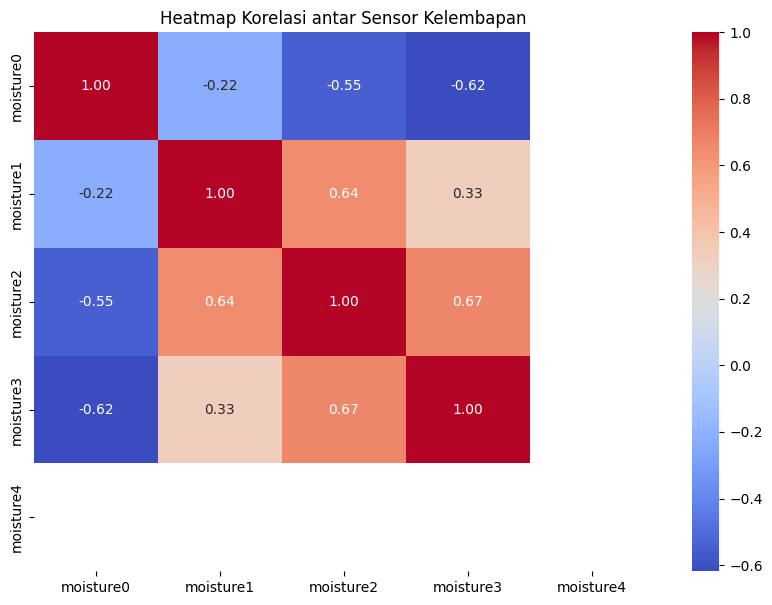

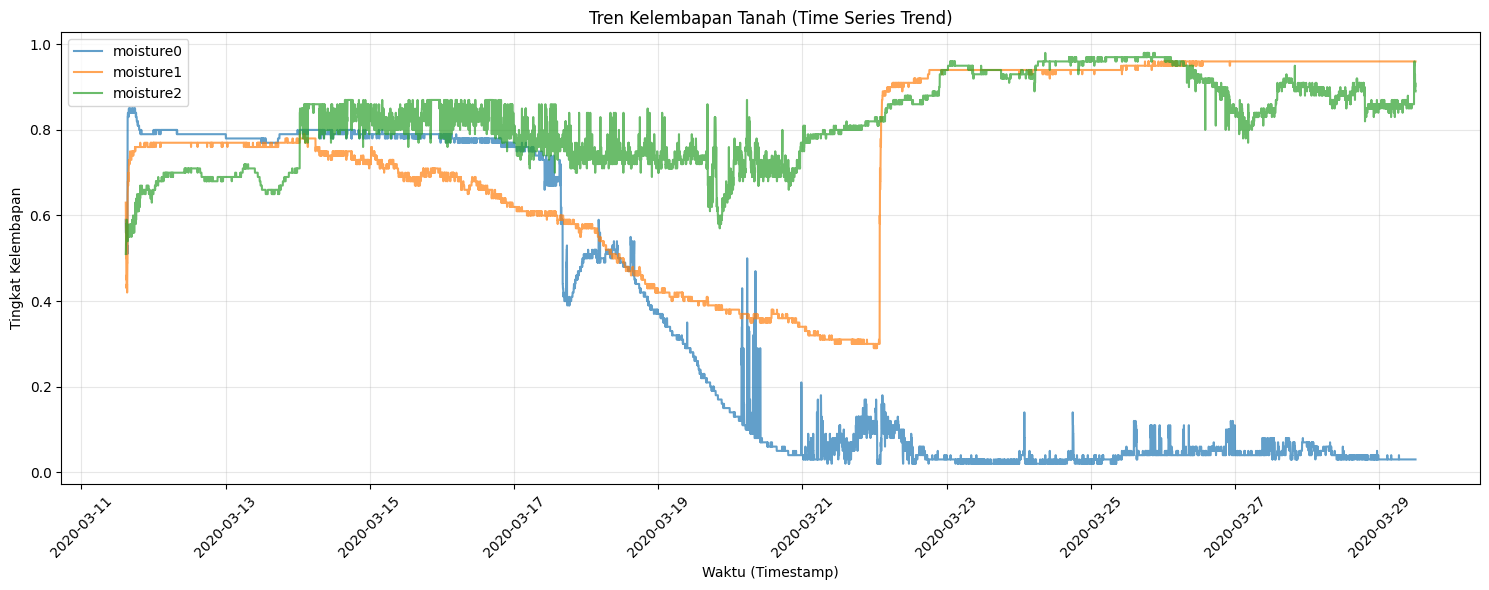

In [57]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[moisture_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi antar Sensor Kelembapan')
plt.show()


plt.figure(figsize=(15, 6))
for col in ['moisture0', 'moisture1', 'moisture2']:
    plt.plot(df['timestamp'], df[col], label=col, alpha=0.7)

plt.title('Tren Kelembapan Tanah (Time Series Trend)')
plt.xlabel('Waktu (Timestamp)')
plt.ylabel('Tingkat Kelembapan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()